In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import os

In [2]:
data = pd.read_csv("./data/raaml_results_gbmlp.csv")
print(list(data.columns))

['task_id', 'method', 'seed', 'config_id', 'model', 'time_5fcv', 'bmp_RMSE', 'bmp_inference_time', 'bmp_energy_consumption', 'status', 'ensembling_RMSE', 'ensembling_inference_time_freq_1500000_cores_1', 'ensembling_energy_consumption_freq_1500000_cores_1', 'ensembling_inference_time_freq_1500000_cores_2', 'ensembling_energy_consumption_freq_1500000_cores_2', 'ensembling_inference_time_freq_1500000_cores_3', 'ensembling_energy_consumption_freq_1500000_cores_3', 'ensembling_inference_time_freq_1500000_cores_4', 'ensembling_energy_consumption_freq_1500000_cores_4', 'ensembling_inference_time_freq_1500000_cores_5', 'ensembling_energy_consumption_freq_1500000_cores_5', 'ensembling_inference_time_freq_1500000_cores_6', 'ensembling_energy_consumption_freq_1500000_cores_6', 'ensembling_inference_time_freq_1500000_cores_7', 'ensembling_energy_consumption_freq_1500000_cores_7', 'ensembling_inference_time_freq_1500000_cores_8', 'ensembling_energy_consumption_freq_1500000_cores_8', 'ensembling_in

In [3]:
data_random = data[data["method"] == "random"]
data_grouped = data.groupby("task_id")

In [4]:
cv_times = {}
for task_id, group in data_grouped:
    times = group["time_5fcv"].values
    cv_times[task_id] = times
    assert np.all(times >= 0), f"Negative time found for task {task_id}"

cv_times_by_model = {}
for task_id, group in data_grouped:
    models = group["model"].unique()
    cv_times_by_model[task_id] = {}
    for model in models:
        model_times = group[group["model"] == model]["time_5fcv"].values
        cv_times_by_model[task_id][model] = model_times

In [5]:
data = []
for task_id, times in cv_times.items():
    mean_time = np.mean(times)
    median_time = np.median(times)
    std_time = np.std(times)
    data.append({
        "task_id": task_id,
        "mean_time": mean_time,
        "median_time": median_time,
        "std_time": std_time
    })
mean_table = pd.DataFrame(data)

In [15]:
thresholds = [np.quantile(mean_table["mean_time"], 0.25), np.quantile(mean_table["mean_time"], 0.75)]  # in seconds
print(f"Thresholds for groups: {thresholds}")

groups = {
    "Fast": mean_table[mean_table["mean_time"] < thresholds[0]]["task_id"].tolist(),
    "Medium": mean_table[(mean_table["mean_time"] >= thresholds[0]) & (mean_table["mean_time"] < thresholds[1])]["task_id"].tolist(),
    "Slow": mean_table[mean_table["mean_time"] >= thresholds[1]]["task_id"].tolist()
}

if not os.path.exists("./data/groups/"):
    os.makedirs("./data/groups/")

for group_name, task_ids in groups.items():
    print(f"Group {group_name}: {len(task_ids)} tasks")
    with open(f"./data/groups/{group_name.lower()}.yaml", "w") as f:
        yaml.dump(task_ids, f)

Thresholds for groups: [190.99357675108416, 326.56230748736687]
Group Fast: 26 tasks
Group Medium: 52 tasks
Group Slow: 26 tasks


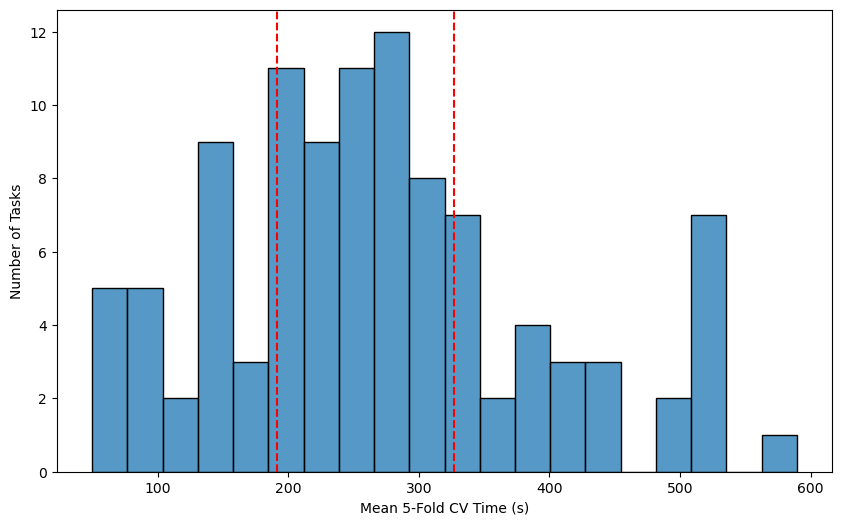

In [18]:

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(mean_table["mean_time"], bins=20, log_scale=(False, False), ax=ax)
#Draw thresholds
for threshold in thresholds:
    ax.axvline(threshold, color='red', linestyle='--')
ax.set_xlabel("Mean 5-Fold CV Time (s)")
ax.set_ylabel("Number of Tasks")
#ax.set_title("Distribution of Mean 5-Fold CV Times Across Tasks")
plt.show()

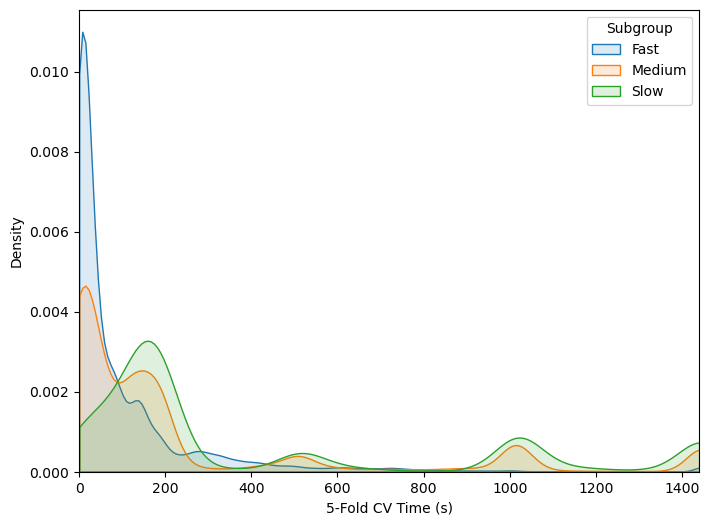

In [17]:
min, max = 0, 1440
fig, ax = plt.subplots(figsize=(8, 6))
for group_name, task_ids in groups.items():
    times = []
    for task_id in task_ids:
        times.extend(cv_times[task_id])
    sns.kdeplot(times, label=group_name, fill=True, alpha=.15, ax=ax, clip=(min, max))
ax.set_xlim(min, max)
ax.set_xlabel("5-Fold CV Time (s)")
ax.set_ylabel("Density")
ax.legend(title="Subgroup")
plt.show()

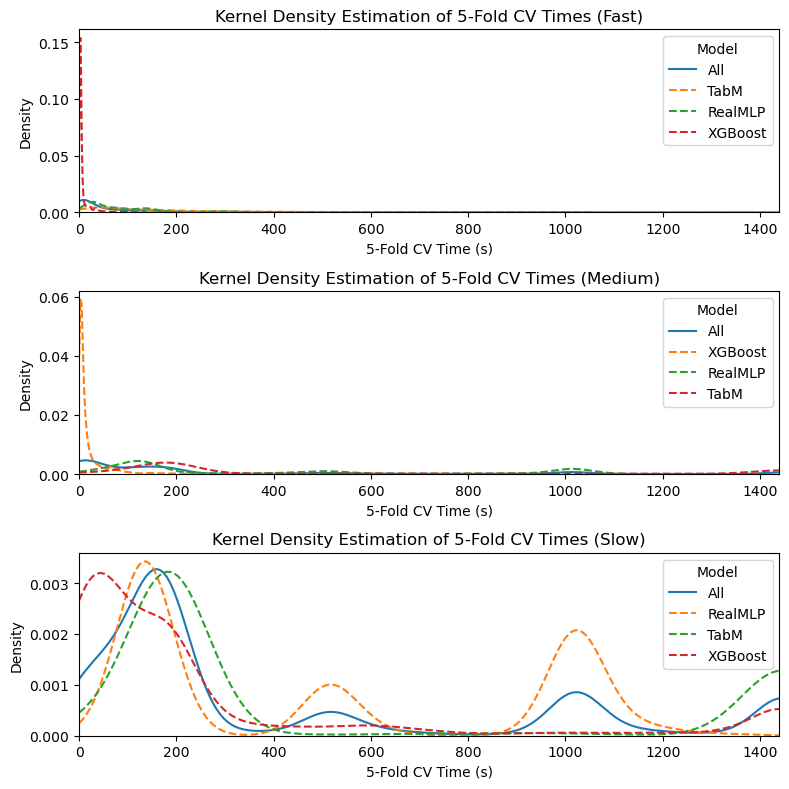

In [9]:
min, max = 0, 1440
fig, ax = plt.subplots(figsize=(8, 8), nrows=3)
for i, (group_name, task_ids) in enumerate(groups.items()):
    times = []
    times_model_specific = {}
    for task_id in task_ids:
        times.extend(cv_times[task_id])
        for model, model_times in cv_times_by_model[task_id].items():
            if model not in times_model_specific:
                times_model_specific[model] = []
            times_model_specific[model].extend(model_times)
    sns.kdeplot(times, label="All", fill=False, alpha=1, ax=ax[i], clip=(min, max))
    for model in times_model_specific:
        sns.kdeplot(times_model_specific[model], label=model, fill=False, ax=ax[i], clip=(min, max), linestyle="--")
    ax[i].set_xlim(min, max)
    ax[i].set_xlabel("5-Fold CV Time (s)")
    ax[i].set_ylabel("Density")
    ax[i].set_title(f"Kernel Density Estimation of 5-Fold CV Times ({group_name})")
    ax[i].legend(title="Model")
plt.tight_layout()
plt.show()

In [10]:
with open("./data/classification_meta.yaml", "r") as f:
    meta_clf = yaml.safe_load(f)
with open("./data/regression_meta.yaml", "r") as f:
    meta_reg = yaml.safe_load(f)

groups_type = {
    "binary": [task_id for task_id, info in meta_clf.items() if info["n_classes"] == 2],
    "multiclass": [task_id for task_id, info in meta_clf.items() if info["n_classes"] > 2],
    "regression": list(meta_reg.keys())
}

for group_name, task_ids in groups_type.items():
    print(f"Group {group_name}: {len(task_ids)} tasks")
    with open(f"./data/groups/{group_name}.yaml", "w") as f:
        yaml.dump(task_ids, f)

Group binary: 41 tasks
Group multiclass: 30 tasks
Group regression: 33 tasks


In [14]:
data = []

for task_id in meta_reg.keys():
    data.append({
        "OpenML Task ID": task_id,
        "Problem Type": "Regression",
        "Average 5-Fold CV Time (s)": mean_table[mean_table["task_id"] == task_id]["mean_time"].values[0],
        "Subgroup by Time": ("Fast" if task_id in groups["Fast"] else
                             "Medium" if task_id in groups["Medium"] else
                             "Slow" if task_id in groups["Slow"] else
                             "Unknown")
    })
for task_id in meta_clf.keys():
    data.append({
        "OpenML Task ID": task_id,
        "Problem Type": "Binary Classification" if meta_clf[task_id]["n_classes"] == 2 else "Multiclass Classification",
        "Average 5-Fold CV Time (s)": mean_table[mean_table["task_id"] == task_id]["mean_time"].values[0],
        "Subgroup by Time": ("Fast" if task_id in groups["Fast"] else
                             "Medium" if task_id in groups["Medium"] else
                             "Slow" if task_id in groups["Slow"] else
                             "Unknown")
    })
data_summary = pd.DataFrame(data)
data_summary.to_latex("./data/task_subgroup_summary.tex", index=False)